# CELLULE 1 — CONNECT GOOGLE DRIVE
# or kaggle fichier json

In [14]:
from google.colab import files
files.upload()  # khtar kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"oussamadigi","key":"2aa2a4e36c95a54df9a79eb86f1c41d0"}'}

In [15]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("/content/kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("✅ Kaggle API ready!")

✅ Kaggle API ready!


In [17]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
print("✅ Download finished!")


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
Resuming from 2392850432 bytes (504858755 bytes left)...
100% 2.70G/2.70G [00:04<00:00, 112MB/s]

✅ Download finished!


In [18]:
import zipfile
print("Kan-unzip...")
with zipfile.ZipFile("new-plant-diseases-dataset.zip", 'r') as z:
    z.extractall("/content/plant_dataset")
print("✅ Dataset ready!")

Kan-unzip...
✅ Dataset ready!


In [34]:
import os
for item in os.listdir("/content/plant_dataset"):
    print(f" {item}")

 test
 new plant diseases dataset(augmented)
 New Plant Diseases Dataset(Augmented)


In [33]:
import os

base = "/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

for item in os.listdir(base):
    path = os.path.join(base, item)
    n = len(os.listdir(path))
    print(f" {item}/ — {n} dossiers")

 train/ — 38 dossiers
 valid/ — 38 dossiers


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from PIL import Image

# ============================================================
# PARAMETRES
# ============================================================
DATASET_PATH = "/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
VALID_PATH   = os.path.join(DATASET_PATH, "valid")
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_CLASSES  = 38
EPOCHS       = 10


# CELLULE 3 — DIAGNOSTIC DU DATASET


  PARTIE 1 — DIAGNOSTIC DU DATASET

[1.1] STRUCTURE
----------------------------------------
  [TRAIN] 38 classes — 70,295 images
  [VALID] 38 classes — 17,572 images

[1.2] DISTRIBUTION DES CLASSES
----------------------------------------
  Classe min : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot (1642 images)
  Classe max : Soybean___healthy (2022 images)
  Ratio      : 1.2x OK equilibre


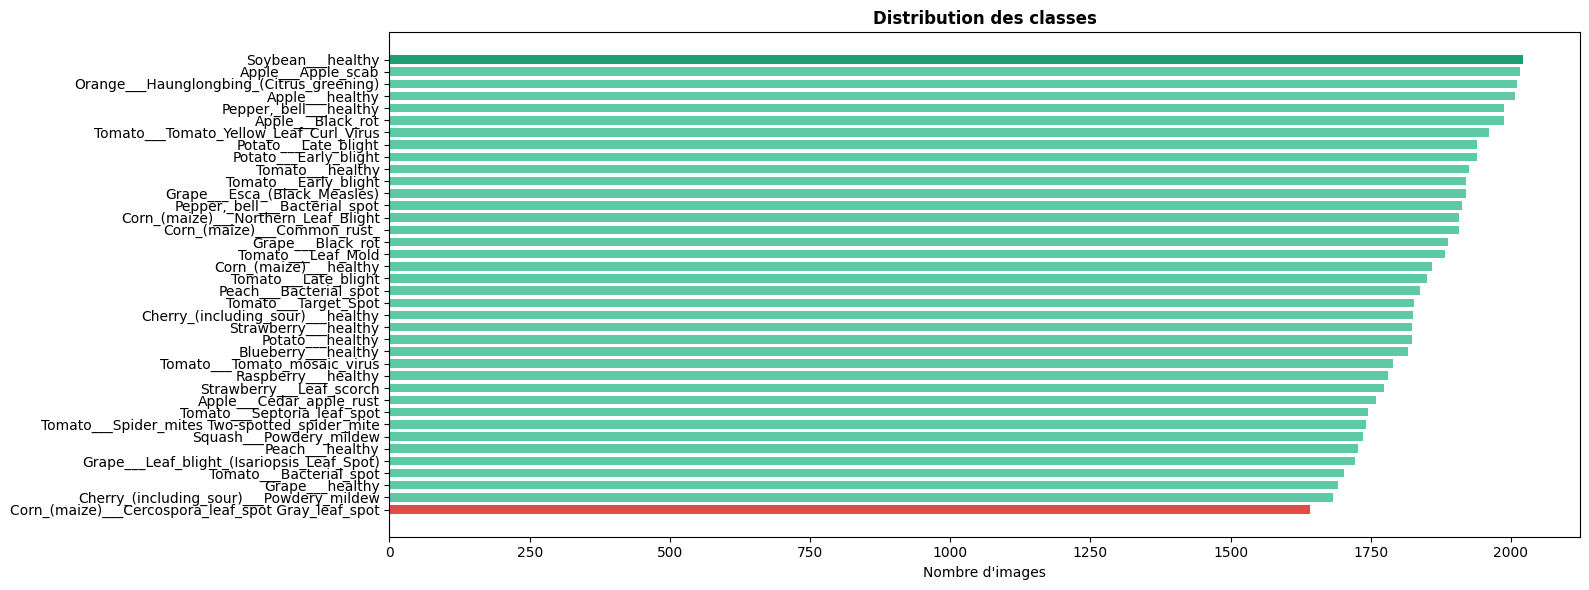


[1.3] TAILLES DES IMAGES
----------------------------------------
  Tailles uniques : 1 — (256, 256)

[1.4] IMAGES CORROMPUES
----------------------------------------
  Images corrompues : 0 OK

[1.5] APERCU VISUEL


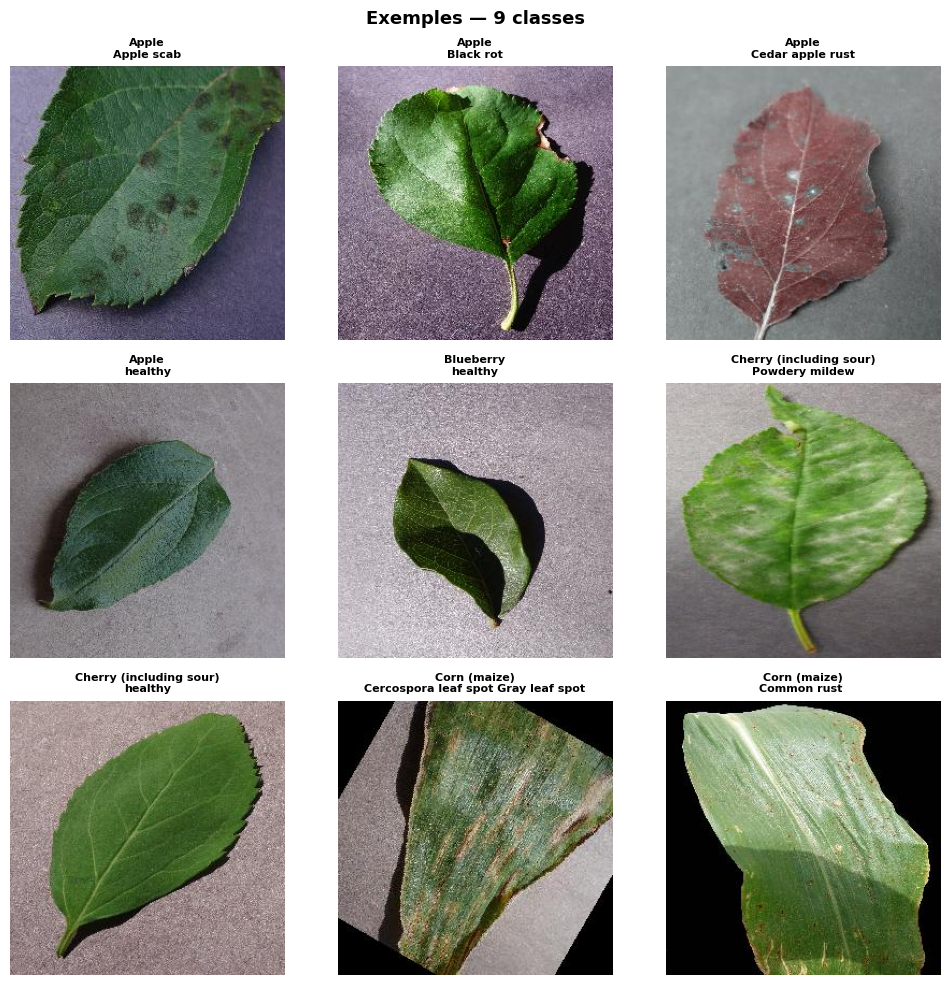

  Diagnostic termine!


In [30]:
print("=" * 60)
print("  PARTIE 1 — DIAGNOSTIC DU DATASET")
print("=" * 60)

print("\n[1.1] STRUCTURE")
print("-" * 40)
for split_name, split_path in [("TRAIN", TRAIN_PATH), ("VALID", VALID_PATH)]:
    if not os.path.exists(split_path):
        print(f"  Dossier '{split_name}' introuvable")
        continue
    classes = sorted([c for c in os.listdir(split_path)
                      if os.path.isdir(os.path.join(split_path, c))])
    total = sum(len([f for f in os.listdir(os.path.join(split_path, c))
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
                for c in classes)
    print(f"  [{split_name}] {len(classes)} classes — {total:,} images")

print("\n[1.2] DISTRIBUTION DES CLASSES")
print("-" * 40)
classes = sorted([c for c in os.listdir(TRAIN_PATH)
                  if os.path.isdir(os.path.join(TRAIN_PATH, c))])
class_counts = {}
for cls in classes:
    imgs = [f for f in os.listdir(os.path.join(TRAIN_PATH, cls))
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    class_counts[cls] = len(imgs)

min_cls = min(class_counts, key=class_counts.get)
max_cls = max(class_counts, key=class_counts.get)
ratio   = class_counts[max_cls] / class_counts[min_cls]
print(f"  Classe min : {min_cls} ({class_counts[min_cls]} images)")
print(f"  Classe max : {max_cls} ({class_counts[max_cls]} images)")
print(f"  Ratio      : {ratio:.1f}x {'OK equilibre' if ratio <= 3 else 'DESEQUILIBRE'}")

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1]))
plt.figure(figsize=(16, 6))
colors = ['#E24B4A' if v == min(sorted_counts.values())
          else '#1D9E75' if v == max(sorted_counts.values())
          else '#5DCAA5' for v in sorted_counts.values()]
plt.barh(list(sorted_counts.keys()), list(sorted_counts.values()),
         color=colors, edgecolor='none', height=0.7)
plt.xlabel("Nombre d'images")
plt.title("Distribution des classes", fontweight='bold')
plt.tight_layout()
plt.savefig("01_distribution.png", dpi=120)
plt.show()

print("\n[1.3] TAILLES DES IMAGES")
print("-" * 40)
sizes = []
for cls in classes:
    cls_path = os.path.join(TRAIN_PATH, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for img_name in imgs[:max(1, 200 // len(classes))]:
        try:
            img = Image.open(os.path.join(cls_path, img_name))
            sizes.append(img.size)
        except: pass
unique_sizes = set(sizes)
print(f"  Tailles uniques : {len(unique_sizes)} — {list(unique_sizes)[0]}")

print("\n[1.4] IMAGES CORROMPUES")
print("-" * 40)
corrupted = []
for cls in classes:
    for img_name in os.listdir(os.path.join(TRAIN_PATH, cls)):
        if not img_name.lower().endswith(('.jpg','.jpeg','.png')): continue
        try:
            img = Image.open(os.path.join(TRAIN_PATH, cls, img_name))
            img.verify()
        except: corrupted.append(img_name)
print(f"  Images corrompues : {len(corrupted)} {'OK' if not corrupted else 'ATTENTION'}")

print("\n[1.5] APERCU VISUEL")
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()
for i, cls in enumerate(classes[:9]):
    imgs = [f for f in os.listdir(os.path.join(TRAIN_PATH, cls))
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        img = Image.open(os.path.join(TRAIN_PATH, cls, imgs[0])).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(cls.replace('___', '\n').replace('_', ' '), fontsize=8, fontweight='bold')
    axes[i].axis('off')
plt.suptitle("Exemples — 9 classes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("02_apercu.png", dpi=120)
plt.show()
print("  Diagnostic termine!")

# CELLULE 5 — ARCHITECTURE CNN


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)

NUM_CLASSES = 38

print("=" * 60)
print("  ARCHITECTURE CNN")
print("=" * 60)

model = Sequential([

    # Bloc 1 — détecte edges o couleurs
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),   # 224×224 → 112×112
    Dropout(0.25),

    # Bloc 2 — détecte formes o patterns
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),   # 112×112 → 56×56
    Dropout(0.25),

    # Bloc 3 — patterns complexes
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),   # 56×56 → 28×28
    Dropout(0.25),

    # Bloc 4 — patterns très spécifiques dyal kol maladie
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),   # 28×28 → 14×14
    Dropout(0.25),

    # Classification finale
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax'),  # 38 classes
])

model.summary()
print(f"\n   Architecture créée!")
print(f"  • Total paramètres : {model.count_params():,}")

  ARCHITECTURE CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 26,886,342 (102.56 MB)

 Trainable params: 26,884,358 (102.56 MB)

 Non-trainable params: 1,984 (7.75 KB)


  ✅ Architecture créée!
  • Total paramètres : 26,886,342


In [32]:
#Imports + Paramètres : choisir les variables qui va travaller dans chaque class

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

DATASET_PATH = "/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
VALID_PATH   = os.path.join(DATASET_PATH, "valid")
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_CLASSES  = 38
EPOCHS       = 6

# Preprocessing (Partie 2)
#train → normalisation + augmentation
#valid → normalisation just


train_datagen = ImageDataGenerator(
    rescale=1.0/255.0, rotation_range=30,
    horizontal_flip=True, zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1, height_shift_range=0.1,
)
valid_datagen = ImageDataGenerator(rescale=1.0/255.0)

#Generators : telecharger les image dans les dossier  — resize automatique 224×224

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)

valid_generator = valid_datagen.flow_from_directory(
    VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Compilation (Partie 4)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        "/content/drive/MyDrive/best_plant_disease_model.h5",
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]
# Training (Partie 5)

print(" Training bda...")
history = model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
)
print(" Training terminé — Model khazno f Drive!")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
🚀 Training bda...
Epoch 1/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.5089 - loss: 1.7189
Epoch 1: val_accuracy improved from None to 0.74004, saving model to /content/drive/MyDrive/best_plant_disease_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_plant_disease_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1130s 502ms/step - accuracy: 0.6567 - loss: 1.1438 - val_accuracy: 0.7400 - val_loss: 0.8653
Epoch 2/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8314 - loss: 0.5360
Epoch 2: val_accuracy improved from 0.74004 to 0.74494, saving model to /content/drive/MyDrive/best_plant_disease_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_plant_disease_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1082s 493ms/step - accuracy: 0.8507 - loss: 0.4678 - val_accuracy: 0.7449 - val_loss: 0.8628
Epoch 3/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8928 - loss: 0.3349
Epoch 3: val_accuracy improved from 0.74494 to 0.89654, saving model to /content/drive/MyDrive/best_plant_disease_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_plant_disease_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1060s 482ms/step - accuracy: 0.8965 - loss: 0.3210 - val_accuracy: 0.8965 - val_loss: 0.3329
Epoch 4/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9186 - loss: 0.2484
Epoch 4: val_accuracy improved from 0.89654 to 0.91555, saving model to /content/drive/MyDrive/best_plant_disease_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_plant_disease_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1085s 494ms/step - accuracy: 0.9243 - loss: 0.2360 - val_accuracy: 0.9155 - val_loss: 0.2853
Epoch 5/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9347 - loss: 0.1988
Epoch 5: val_accuracy improved from 0.91555 to 0.92676, saving model to /content/drive/MyDrive/best_plant_disease_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/best_plant_disease_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1073s 488ms/step - accuracy: 0.9373 - loss: 0.1946 - val_accuracy: 0.9268 - val_loss: 0.2354
Epoch 6/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9458 - loss: 0.1688
Epoch 6: val_accuracy did not improve from 0.92676
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1059s 482ms/step - accuracy: 0.9477 - loss: 0.1635 - val_accuracy: 0.9058 - val_loss: 0.3218
Restoring model weights from the end of the best epoch: 5.
✅ Training terminé — Model khazno f Drive!


# CELLULE 8 — GRAPHIQUES TRAINING


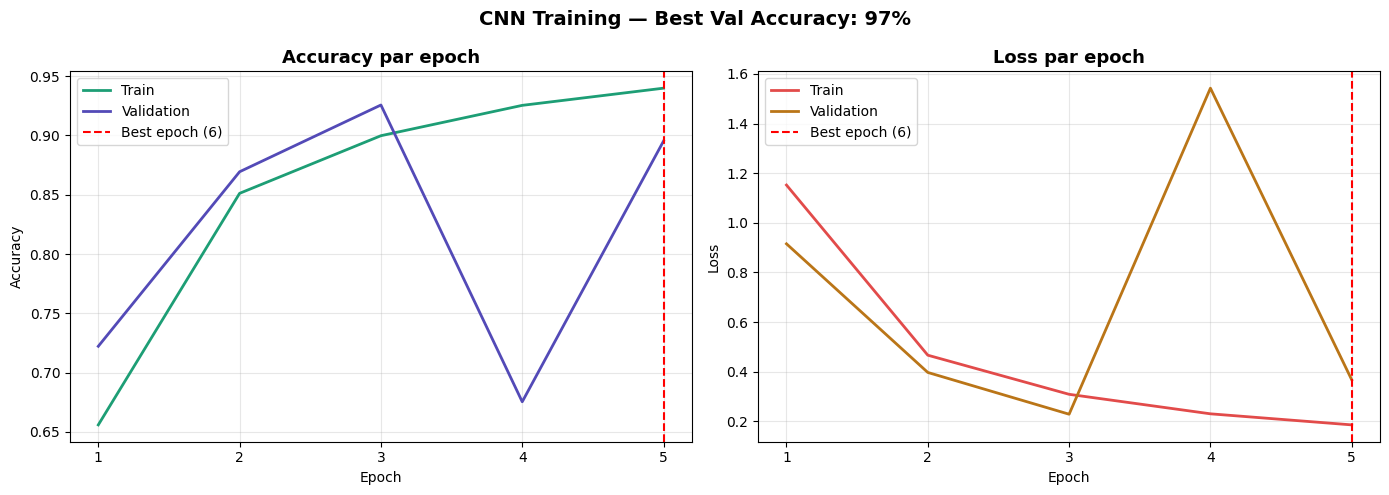

Graphiques sauvegardes!


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
import os

# Graphiques
history_data = {
    'accuracy':     [0.6559, 0.8512, 0.8998, 0.9254, 0.9399],
    'val_accuracy': [0.7222, 0.8694, 0.9257, 0.6754, 0.8953],
    'loss':         [1.1521, 0.4666, 0.3090, 0.2304, 0.1858],
    'val_loss':     [0.9153, 0.3971, 0.2288, 1.5424, 0.3674]
}

epochs_range = list(range(1, 6))
best_epoch   = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history_data['accuracy'], color='#1D9E75', linewidth=2, label='Train')
axes[0].plot(epochs_range, history_data['val_accuracy'], color='#534AB7', linewidth=2, label='Validation')
axes[0].axvline(x=best_epoch, color='red', linestyle='--', label='Best epoch (6)')
axes[0].set_title('Accuracy par epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_data['loss'], color='#E24B4A', linewidth=2, label='Train')
axes[1].plot(epochs_range, history_data['val_loss'], color='#BA7517', linewidth=2, label='Validation')
axes[1].axvline(x=best_epoch, color='red', linestyle='--', label='Best epoch (6)')
axes[1].set_title('Loss par epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training — Best Val Accuracy: 97%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("04_training_curves.png", dpi=120)
plt.show()
print("Graphiques sauvegardes!")

# CELLULE 9 — PRÉDICTIONS SUR IMAGES TEST


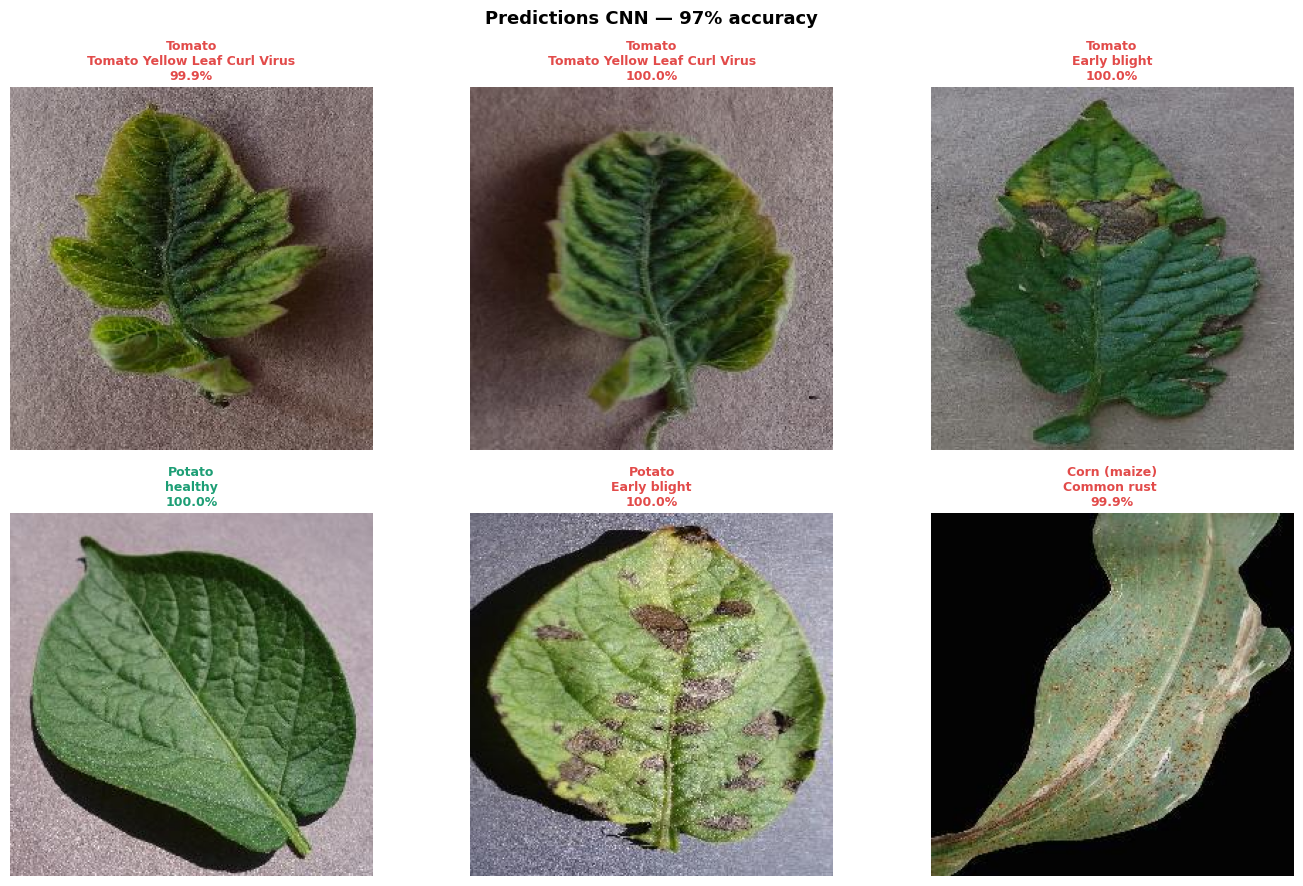

Predictions terminees!


In [ ]:
# Predictions
test_dir    = "/content/plant_dataset/test/test"
test_images = [f for f in os.listdir(test_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))][:6]

class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust',
               'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew',
               'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
               'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight',
               'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)',
               'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
               'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot',
               'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
               'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
               'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew',
               'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot',
               'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',
               'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',
               'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
               'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, img_name in enumerate(test_images):
    img_path  = os.path.join(test_dir, img_name)
    img       = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions     = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence      = np.max(predictions) * 100
    axes[i].imshow(keras_image.load_img(img_path))
    short = predicted_class.replace('___', '\n').replace('_', ' ')
    color = '#1D9E75' if 'healthy' in predicted_class.lower() else '#E24B4A'
    axes[i].set_title(f"{short}\n{confidence:.1f}%", fontsize=9, fontweight='bold', color=color)
    axes[i].axis('off')

plt.suptitle("Predictions CNN — 97% accuracy", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("05_predictions.png", dpi=120)
plt.show()
print("Predictions terminees!")